# Improvement Experiments — So sánh 3 cải tiến vs Baseline

| Experiment | Mô tả |
|---|---|
| **Baseline** | LightGBM, XGBoost, RF, Stacking — config hiện tại |
| **Exp 1** | + Target encoding `hour_of_day` (cross-validated, smoothed) |
| **Exp 2** | + Calibrated XGB/LGB bên trong Stacking (Isotonic) |
| **Exp 3** | + Optuna tuned RandomForest (50 trials) |

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})

print('Ready')

Ready


## 1. Run All Experiments

In [ ]:
from pipelines.training.improvements import run_all_experiments

DATA_PATH = PROJECT_ROOT / 'data' / 'raw' / 'Completion_prediction__dataset__hashing.csv'

results = run_all_experiments(str(DATA_PATH), sep='\t')

Loaded: 4,441 rows × 29 columns
Dropped leakage: ['est_time_arrival', 'est_distance_arrival', 'estimate_dropoff_time', 'total_pay']
Dropped IDs: ['order_id', 'matching_batch_id', 'driver_id']
Dropped constant: ['travel_mode']
Imputed eta_std: 449 NaN → 0
Imputed eda_std: 449 NaN → 0
Created 20 derived features

EXP 0: BASELINE (current)
  LightGBM... AUC=0.6461
  XGBoost... AUC=0.6486
  RandomForest... AUC=0.6732
  Stacking... AUC=0.6721

EXP 1: + Target Encoding hour_of_day
  Added hour_target_enc (smoothing=10)
  LightGBM... AUC=0.6449
  XGBoost... AUC=0.6498
  RandomForest... AUC=0.6717
  Stacking... AUC=0.6707

EXP 2: + Calibrated XGB/LGB in Stacking
  CalibratedStacking... AUC=0.6725

EXP 3: Optuna Tuned RandomForest
  Tuning (50 trials)...
  Best params: {'n_estimators': 672, 'max_depth': 8, 'min_samples_leaf': 5, 'min_samples_split': 50, 'max_features': 0.3}
  Best AUC: 0.6759
  TunedRF... AUC=0.6759

FINAL COMPARISON
                         AUC-ROC    AUC-PR  Log Loss        F

## 2. Comparison Table

In [ ]:
comparison = results['comparison']
comparison.style.background_gradient(cmap='RdYlGn', subset=['AUC-ROC', 'AUC-PR', 'F1']).background_gradient(cmap='RdYlGn_r', subset=['Log Loss', 'ECE'])

,AUC-ROC,AUC-PR,Log Loss,F1,ECE
TunedRF,0.675865,0.617944,0.642344,0.575551,0.009255
Baseline_RandomForest,0.673197,0.615605,0.644255,0.572104,0.009004
CalStacking,0.672505,0.614694,0.644747,0.568783,0.014158
Baseline_Stacking,0.672134,0.614438,0.644980,0.564075,0.013369
TargetEnc_RandomForest,0.671666,0.614008,0.644792,0.575314,0.009563
TargetEnc_Stacking,0.670731,0.611566,0.645709,0.572257,0.018571
TargetEnc_XGBoost,0.649815,0.593280,0.714257,0.557964,0.122814
Baseline_XGBoost,0.648560,0.587993,0.715190,0.555836,0.124377
Baseline_LightGBM,0.646140,0.595971,0.701931,0.562249,0.109046
TargetEnc_LightGBM,0.644920,0.585239,0.706913,0.560933,0.114624


## 3. AUC-ROC Comparison Chart

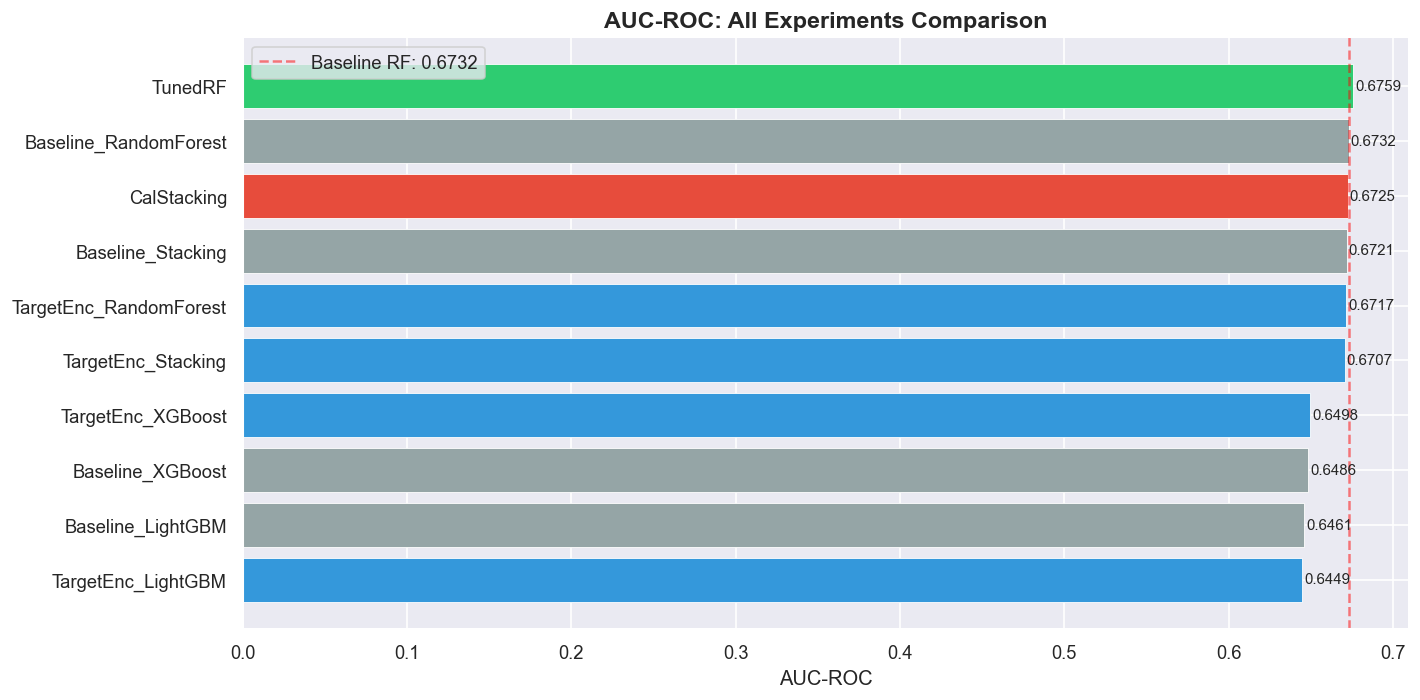

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

# Color by experiment group
colors = []
for name in comparison.index:
    if name.startswith('Baseline'):
        colors.append('#95a5a6')  # grey
    elif name.startswith('TargetEnc'):
        colors.append('#3498db')  # blue
    elif name.startswith('Cal'):
        colors.append('#e74c3c')  # red
    elif name.startswith('Tuned'):
        colors.append('#2ecc71')  # green
    else:
        colors.append('#f39c12')  # orange

bars = ax.barh(comparison.index[::-1], comparison['AUC-ROC'].values[::-1],
               color=colors[::-1], edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, comparison['AUC-ROC'].values[::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

# Baseline RF line
if 'Baseline_RandomForest' in comparison.index:
    baseline_auc = comparison.loc['Baseline_RandomForest', 'AUC-ROC']
    ax.axvline(baseline_auc, color='red', linestyle='--', alpha=0.5, label=f'Baseline RF: {baseline_auc:.4f}')
    ax.legend()

ax.set_title('AUC-ROC: All Experiments Comparison', fontweight='bold', fontsize=14)
ax.set_xlabel('AUC-ROC')
plt.tight_layout()
plt.show()

## 4. Multi-metric Comparison

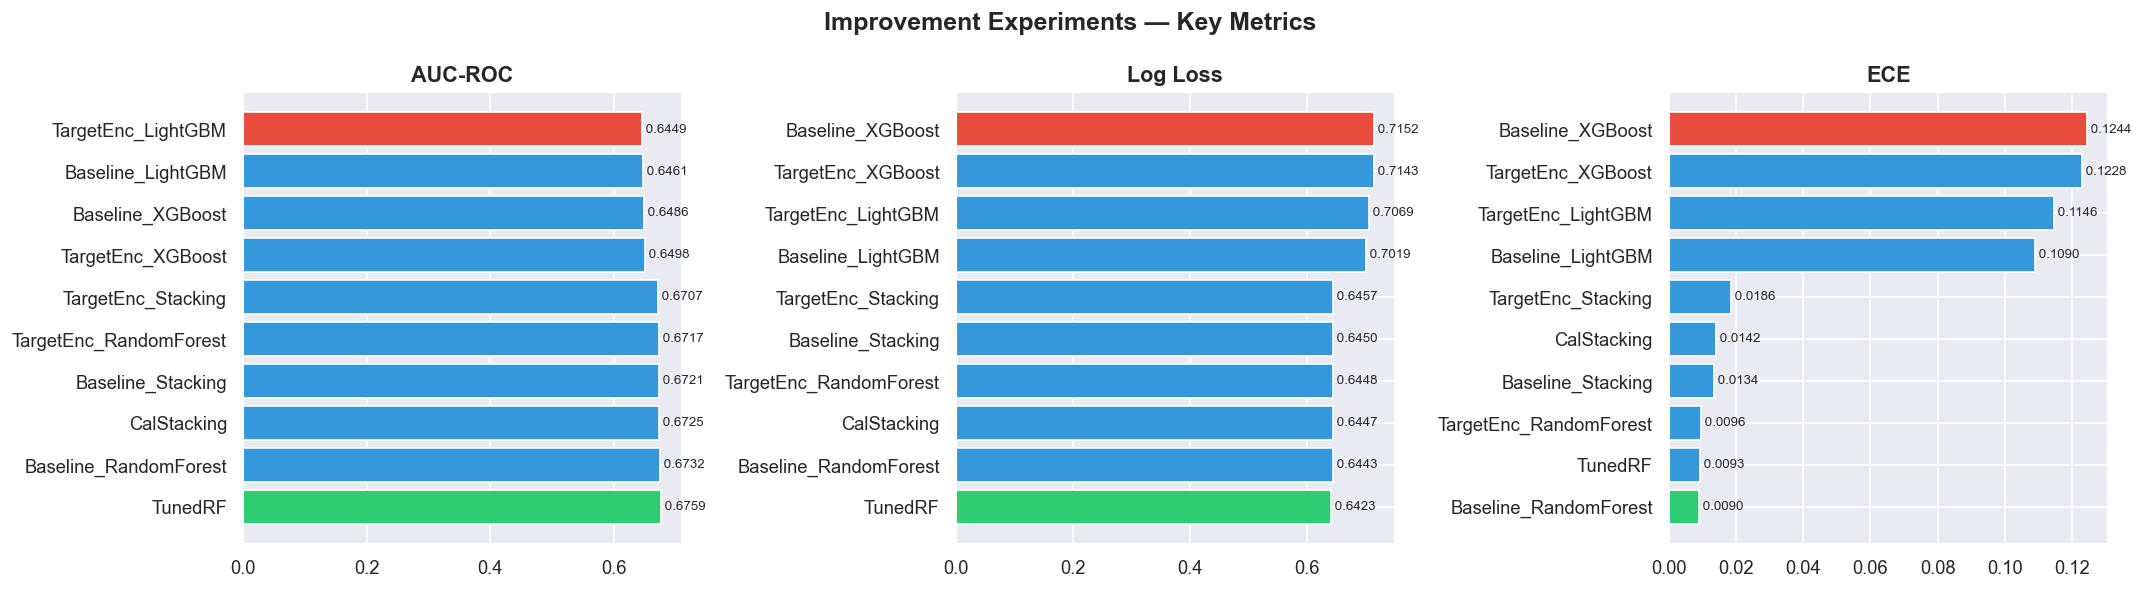

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, metric in enumerate(['AUC-ROC', 'Log Loss', 'ECE']):
    ax = axes[i]
    vals = comparison[metric].sort_values(ascending=(metric != 'AUC-ROC'))
    c = ['#2ecc71' if v == vals.max() else '#e74c3c' if v == vals.min() else '#3498db'
         for v in vals.values] if metric == 'AUC-ROC' else \
        ['#2ecc71' if v == vals.min() else '#e74c3c' if v == vals.max() else '#3498db'
         for v in vals.values]
    ax.barh(vals.index, vals.values, color=c, edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    for j, val in enumerate(vals.values):
        ax.text(val, j, f' {val:.4f}', va='center', fontsize=8)

plt.suptitle('Improvement Experiments — Key Metrics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Delta vs Baseline

In [ ]:
# So sánh mỗi improvement vs baseline tương ứng
if 'Baseline_RandomForest' in comparison.index:
    baseline_rf = comparison.loc['Baseline_RandomForest']
    print('Delta vs Baseline RandomForest (best baseline):')
    print('=' * 60)
    for name in comparison.index:
        if name == 'Baseline_RandomForest':
            continue
        row = comparison.loc[name]
        delta_auc = row['AUC-ROC'] - baseline_rf['AUC-ROC']
        delta_ll = row['Log Loss'] - baseline_rf['Log Loss']
        delta_ece = row['ECE'] - baseline_rf['ECE']
        sign_auc = '+' if delta_auc >= 0 else ''
        sign_ll = '+' if delta_ll >= 0 else ''
        sign_ece = '+' if delta_ece >= 0 else ''
        print(f'{name:30s}  AUC: {sign_auc}{delta_auc:.4f}  LL: {sign_ll}{delta_ll:.4f}  ECE: {sign_ece}{delta_ece:.4f}')

Delta vs Baseline RandomForest (best baseline):
TunedRF                         AUC: +0.0027  LL: -0.0019  ECE: +0.0003
CalStacking                     AUC: -0.0007  LL: +0.0005  ECE: +0.0052
Baseline_Stacking               AUC: -0.0011  LL: +0.0007  ECE: +0.0044
TargetEnc_RandomForest          AUC: -0.0015  LL: +0.0005  ECE: +0.0006
TargetEnc_Stacking              AUC: -0.0025  LL: +0.0015  ECE: +0.0096
TargetEnc_XGBoost               AUC: -0.0234  LL: +0.0700  ECE: +0.1138
Baseline_XGBoost                AUC: -0.0246  LL: +0.0709  ECE: +0.1154
Baseline_LightGBM               AUC: -0.0271  LL: +0.0577  ECE: +0.1000
TargetEnc_LightGBM              AUC: -0.0283  LL: +0.0627  ECE: +0.1056


## 6. Optuna Best Params

In [ ]:
if results.get('best_optuna_params'):
    print('Best RandomForest params from Optuna:')
    for k, v in results['best_optuna_params'].items():
        print(f'  {k}: {v}')
else:
    print('Optuna not run (install: pip install optuna)')

Best RandomForest params from Optuna:
  n_estimators: 672
  max_depth: 8
  min_samples_leaf: 5
  min_samples_split: 50
  max_features: 0.3
